#  Notebook 3 — CLV Model Training & Evaluation
**Project:** E-Commerce CLV Micro-Segmentation

---
**Sections:**
1. Load data and features
2. Train/test split
3. Train Gradient Boosting classifier
4. Classification report (F1, precision, recall)
5. Confusion matrix
6. ROC-AUC curve
7. Feature importance
8. SHAP summary plot

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Data & Trained Model

In [2]:
conn = sqlite3.connect('../data/processed/customers_clean.db')
df = pd.read_sql('SELECT * FROM customers', conn)
conn.close()

clf = joblib.load('../models/clv_classifier.pkl')
le  = joblib.load('../models/clv_label_encoder.pkl')

from src.features import get_ml_feature_cols
feature_cols = [c for c in get_ml_feature_cols() if c in df.columns]

X = df[feature_cols].fillna(0)
y = le.transform(df['CLV_Band'].astype(str))

print(f'Features : {len(feature_cols)}')
print(f'Samples  : {len(X):,}')
print(f'Classes  : {list(le.classes_)}')
print(f'\nCLV Band distribution:\n{df["CLV_Band"].value_counts()}')

Features : 12
Samples  : 350
Classes  : ['High', 'Low', 'Medium']

CLV Band distribution:
CLV_Band
Low       271
High       58
Medium     21
Name: count, dtype: int64


## 2. Train / Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# Cross-validation (5-fold)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1_weighted')
print(f'\n5-Fold Cross-Val F1 (weighted):')
print(f'  Scores : {cv_scores.round(4)}')
print(f'  Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Train: 280 | Test: 70

5-Fold Cross-Val F1 (weighted):
  Scores : [0.9848 1.     1.     1.     0.9499]
  Mean   : 0.9869 ± 0.0194


## 3. Classification Report

In [4]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        12
         Low       1.00      0.98      0.99        54
      Medium       0.80      1.00      0.89         4

    accuracy                           0.99        70
   macro avg       0.93      0.99      0.96        70
weighted avg       0.99      0.99      0.99        70



In [5]:
# ROC-AUC
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f'ROC-AUC (weighted OvR): {auc:.4f}')

ROC-AUC (weighted OvR): 0.9998


## 4. Confusion Matrix

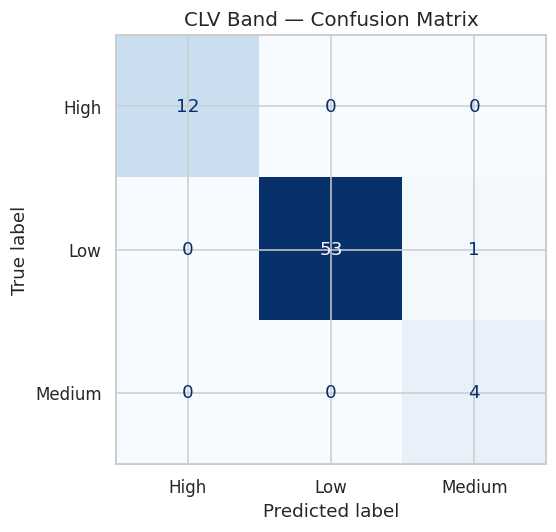

Saved: model_confusion_matrix.png ✅


In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('CLV Band — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('model_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: model_confusion_matrix.png ✅')

## 5. ROC Curves (One-vs-Rest)

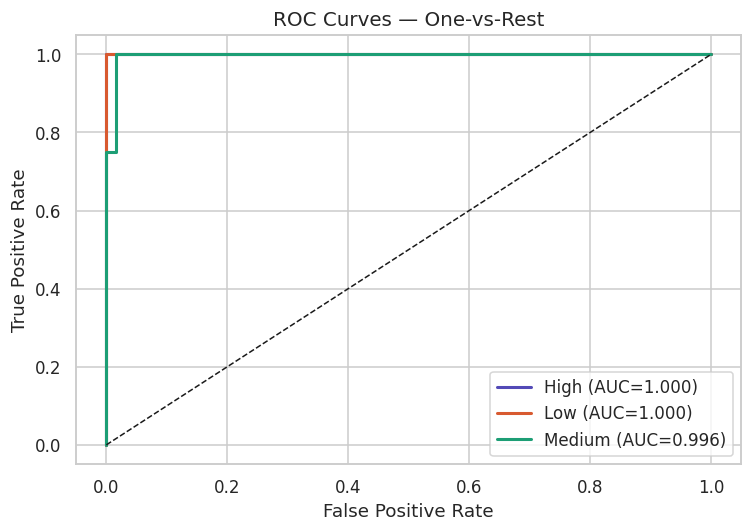

Saved: model_roc_curves.png ✅


In [7]:
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
colors = ['#534AB7', '#D85A30', '#1D9E75']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    class_auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC={class_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('model_roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved: model_roc_curves.png ✅')

## 6. Feature Importance

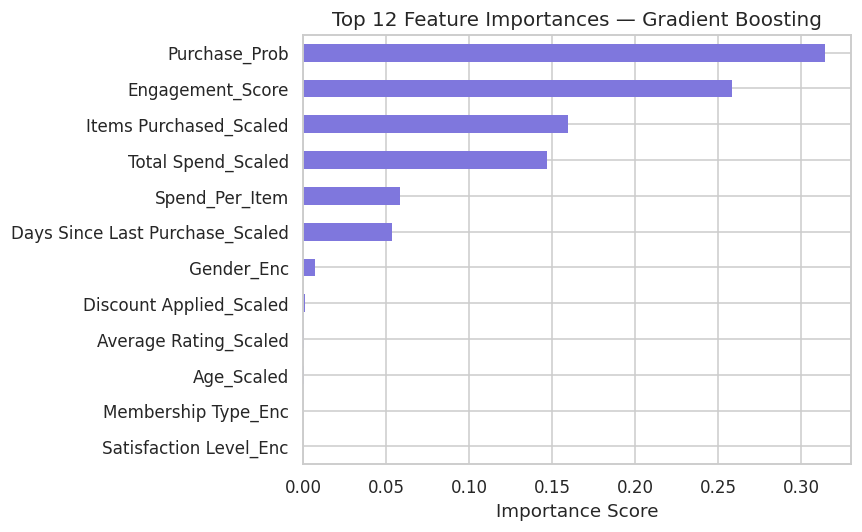

Saved: model_feature_importance.png ✅

Top 5 features:
Purchase_Prob             0.314654
Engagement_Score          0.258501
Items Purchased_Scaled    0.159473
Total Spend_Scaled        0.146673
Spend_Per_Item            0.058277


In [8]:
importances = pd.Series(clf.feature_importances_, index=feature_cols)
top12 = importances.nlargest(12).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
top12.plot(kind='barh', ax=ax, color='#7F77DD', edgecolor='none')
ax.set_title('Top 12 Feature Importances — Gradient Boosting', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('model_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: model_feature_importance.png ✅')
print('\nTop 5 features:')
print(importances.nlargest(5).to_string())

## 7. SHAP Summary Plot

PermutationExplainer explainer: 71it [00:17,  3.88it/s]                                    


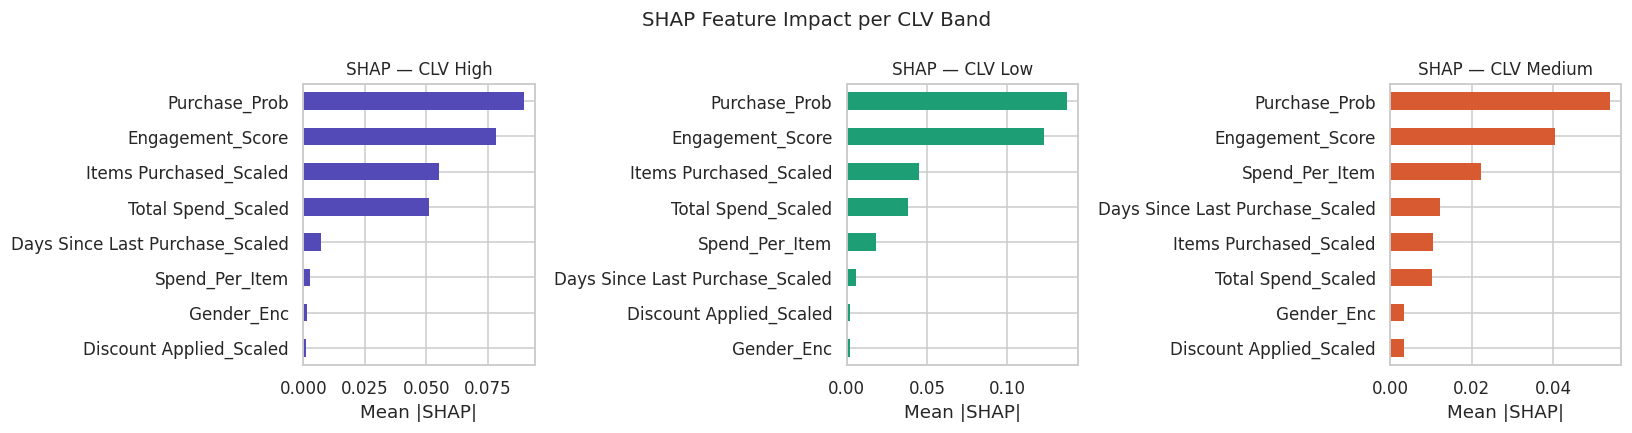

Saved: model_shap.png ✅


In [9]:
try:
    import warnings
    from tqdm import TqdmWarning
    warnings.filterwarnings('ignore', category=TqdmWarning)
    import shap

    try:
        sample_source = X_test
    except NameError:
        try:
            sample_source = X
        except NameError:
            try:
                sample_source = df[feature_cols].fillna(0)
            except NameError:
                import sqlite3
                conn = sqlite3.connect('../data/processed/customers_clean.db')
                df = pd.read_sql('SELECT * FROM customers', conn)
                conn.close()
                from src.features import get_ml_feature_cols
                feature_cols = [c for c in get_ml_feature_cols() if c in df.columns]
                sample_source = df[feature_cols].fillna(0)

    sample = sample_source.sample(min(200, len(sample_source)), random_state=42)
    
    # Use LinearExplainer-style workaround: compute per-class explainers
    fig, axes = plt.subplots(1, len(le.classes_), figsize=(5 * len(le.classes_), 4))
    
    for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
        from sklearn.ensemble import GradientBoostingClassifier
        from sklearn.multiclass import OneVsRestClassifier
        # Use kernel explainer on predict_proba for class i
        f = lambda x: clf.predict_proba(x)[:, i]
        explainer = shap.Explainer(f, sample)
        shap_vals = explainer(sample)
        imp = pd.Series(np.abs(shap_vals.values).mean(axis=0), index=sample.columns).nlargest(8).sort_values()
        imp.plot(kind='barh', ax=ax, color=['#534AB7','#1D9E75','#D85A30'][i % 3], edgecolor='none')
        ax.set_title(f'SHAP — CLV {cls}', fontsize=11)
        ax.set_xlabel('Mean |SHAP|')
    
    plt.suptitle('SHAP Feature Impact per CLV Band', fontsize=13)
    plt.tight_layout()
    plt.savefig('model_shap.png', bbox_inches='tight')
    plt.show()
    print('Saved: model_shap.png ✅')
except Exception as e:
    print(f'SHAP skipped: {e}')
    print('Using feature importance chart instead (already saved above)')

## 8. Final Summary

In [10]:
print('=' * 50)
print('   MODEL EVALUATION SUMMARY')
print('=' * 50)
print(f'Algorithm         : Gradient Boosting Classifier')
print(f'Train samples     : {len(X_train):,}')
print(f'Test samples      : {len(X_test):,}')
print(f'Features used     : {len(feature_cols)}')
print(f'ROC-AUC (OvR)     : {auc:.4f}')
print(f'CV F1 (mean)      : {cv_scores.mean():.4f}')
print('\nCharts saved:')
for f in ['model_confusion_matrix.png','model_roc_curves.png',
          'model_feature_importance.png','model_shap.png']:
    print(f'  📊 notebooks/{f}')
print('\n✅ Notebook 3 complete!')

   MODEL EVALUATION SUMMARY
Algorithm         : Gradient Boosting Classifier
Train samples     : 280
Test samples      : 70
Features used     : 12
ROC-AUC (OvR)     : 0.9998
CV F1 (mean)      : 0.9869

Charts saved:
  📊 notebooks/model_confusion_matrix.png
  📊 notebooks/model_roc_curves.png
  📊 notebooks/model_feature_importance.png
  📊 notebooks/model_shap.png

✅ Notebook 3 complete!
